<a href="https://colab.research.google.com/github/ananya2006sarkar/house-price-prediction/blob/main/house_price-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing the dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import sklearn.datasets #did not need this
from xgboost import XGBRegressor
from sklearn import metrics


importing datasets from sklearn datasets

In [ ]:
house_price_dataset = pd.read_csv('/Housing.csv')
print(house_price_dataset)
house_price_dataset.head()

        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating aircond

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
house_price_dataset.shape

(545, 13)

In [ ]:
house_price_dataset.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
house_price_data= house_price_dataset.describe()
house_price_data.head()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000


 understanding the correlation btw th features
 1. positive correlation
 2. negative correlation

<Axes: >

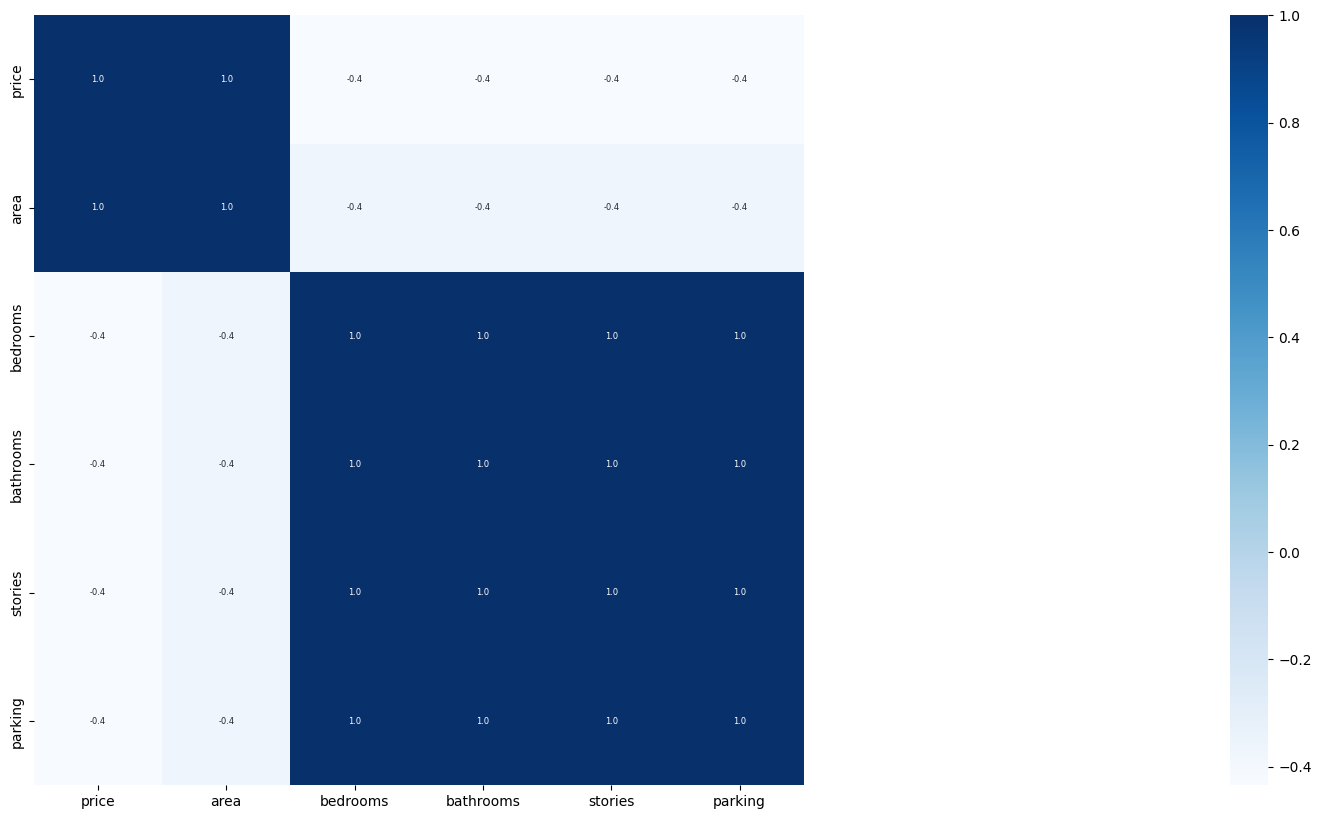

In [ ]:
 correlation = house_price_data.corr()
 #constructing the correlation using heatmap
 plt.figure(figsize=(110,10))
 sns.heatmap(correlation, cbar=True , square=True , fmt='.1f' , annot=True , annot_kws= {'size':6}, cmap='Blues')

In [ ]:
X=house_price_dataset.drop(['price'], axis = 1)
Y = house_price_dataset['price']
print(X)
print(Y)

     area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    7420         4          2        3      yes        no       no   
1    8960         4          4        4      yes        no       no   
2    9960         3          2        2      yes        no      yes   
3    7500         4          2        2      yes        no      yes   
4    7420         4          1        2      yes       yes      yes   
..    ...       ...        ...      ...      ...       ...      ...   
540  3000         2          1        1      yes        no      yes   
541  2400         3          1        1       no        no       no   
542  3620         2          1        1      yes        no       no   
543  2910         3          1        1       no        no       no   
544  3850         3          1        2      yes        no       no   

    hotwaterheating airconditioning  parking prefarea furnishingstatus  
0                no             yes        2      yes        furnished  
1

In [ ]:
X_train , X_test , Y_train , Y_test= train_test_split(X,Y , test_size= 0.2 , random_state=2)
print(X.shape , X_train.shape , X_test.shape)

(545, 12) (436, 12) (109, 12)


In [ ]:
# Automatically convert all 'object' columns to 'category'
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype('category')


model training
XGBoost regressor



In [ ]:
model = XGBRegressor(enable_categorical=True)

In [ ]:
model.fit(X_train , Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

In [ ]:
training_data_prediction = model.predict(X_train)
print(training_data_prediction)

[ 3437637.5  4266591.   2668082.5  4787158.   4200143.   6989735.5
  2939936.5  2664837.2  6930625.5  4766770.   3323263.8  2949949.2
  6027032.5  5817667.   7800610.   4129446.5  5198711.5  4634231.5
  7822496.5  4230385.5  4177434.8  2658310.5  5234440.   4378945.
  3920028.2  4029942.5  6796436.5  9233010.   4665360.5  3161739.8
  3771301.8  3067605.5  2373787.2  4022908.   4262040.   2907373.2
  4880897.   3655500.   1917677.5  7985126.5  4092745.  12187961.
  8527664.   7397872.5  4025292.5  3215165.2  4296617.   3597510.8
  3375032.5  2506003.   5914839.5  4022023.5  3861385.5  3209968.8
  4135265.8  5314606.5  3640324.   3809019.8  3624571.5  4196324.
  7481135.   4265552.   5931341.   2788854.8  3803684.8  5540266.5
  6672290.5  5862087.5  5498747.   5596531.5  3316246.5  3617889.8
  2822821.   4869773.   5257766.   3721025.   5894736.5  4226604.5
  6762519.   5394233.   3085471.5  3579544.5  6656209.   4917530.5
  5876136.5  8387199.   2717370.2  3278769.   9782583.   4127400.

In [ ]:
 #R squared error
score_1  = metrics.r2_score(Y_train , training_data_prediction)
print(score_1)

0.9975634813308716


In [ ]:
#mean squared error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)
print(score_2)

47851.1796875


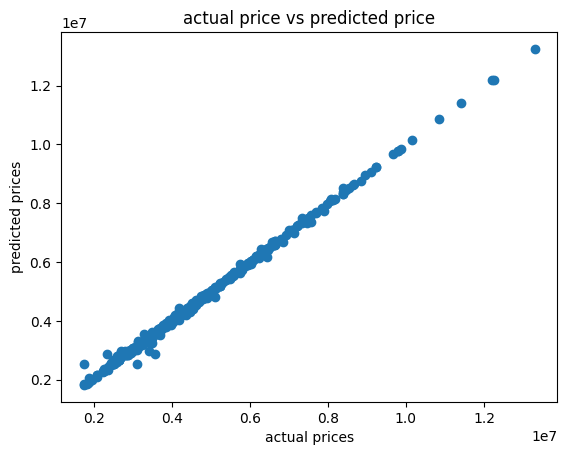

In [ ]:
plt.scatter(Y_train , training_data_prediction)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual price vs predicted price")
plt.show()

Predicting test data

In [ ]:
test_data_prediction = model.predict(X_test)
print(test_data_prediction)

[ 3205051.5  6120804.5  3552144.2  4004144.2  5511685.   4319160.
  4588964.5  2720326.   2444463.5  4547197.   3139156.   3128151.
  3509421.   4656609.   5182276.5  6393436.5  6533549.   4267710.
  3490652.8  4412065.   4233258.   4217297.5  4482056.5  7126553.
  2491301.5  3181400.8  3002289.8  4504164.5  4472985.   3604895.
  4001946.   3357525.5  4004690.   4745126.   3721475.8  6795511.
  2810111.   8623087.   5907341.   2707364.2  5560885.   2948707.5
  3085160.5  3794887.   2765155.5  4211264.5  2360353.5  3240900.
  4507364.   4453498.   8325105.5  6097083.   2804625.5  3002289.8
  3500370.5  5451112.5  4063269.   4340202.   2272327.5  6752871.5
  3058644.5  3502724.8  4101191.2  6183665.  10147847.   6427790.5
  3712854.5  4686296.   2859574.   7607029.   4969248.5  4332208.
  6151146.5  5884605.5  4453011.5  5913154.5  6766189.5  6081662.5
  6175735.5  4984201.5  6081808.5  4221917.5  4474179.5  2579480.5
  3844379.8  4073272.2  9535415.   6616297.5  3868796.2  4441434.
  40

In [ ]:
score1  = metrics.r2_score(Y_test , test_data_prediction)
print("r square error:", score_1)
score2 = metrics.mean_absolute_error(Y_test, test_data_prediction)
print("mean squared error:",score_2)

r square error: 0.9975634813308716
mean squared error: 47851.1796875


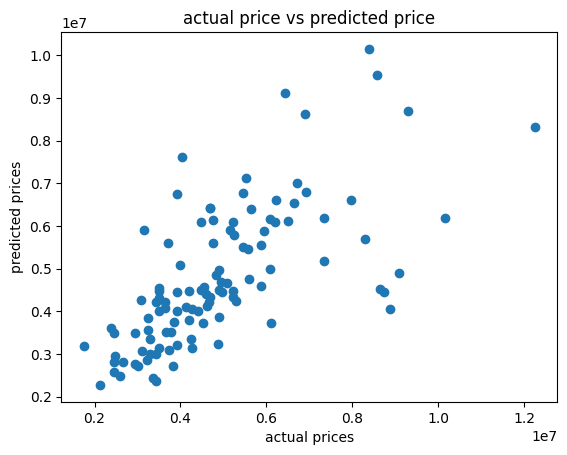

In [ ]:
plt.scatter(Y_test , test_data_prediction)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.title("actual price vs predicted price")
plt.show()